<a href="https://colab.research.google.com/github/MariamNSiciliano/Projeto_Lyme/blob/main/Doenca_de_lyme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJETO: ANÁLISE DE DADOS SOBRE A DOENÇA DE LYME**

### Neste projeto, utilizamos o Lyme Disease Dataset disponibilizado no Kaggle para realizar uma análise exploratória de dados. O objetivo principal é identificar tendências geográficas e temporais, além de possíveis correlações entre variáveis demográficas e a incidência da doença. Por meio dessa análise, buscamos fornecer insights que possam apoiar estudos epidemiológicos, políticas de saúde pública ou novos modelos preditivos para monitoramento e prevenção.

### **Link:** https://www.kaggle.com/datasets/tahmidmir/lyme-disease-dataset?resource=download
---
## **👤 Integrante do Projeto:**
* ### Mariam Neves Siciliano | mariamnsiciliano@gmail.com

# **🔨 FASE 0 - PREPARAÇÃO E CONTEXTUALIZAÇÃO**
###**Objetivo:** Importação das principais bibliotecas: pandas, numpy, matplotlib.pyplot, seaborn.

## **☑️ ETAPA 1 - IMPORTAÇÃO DAS BIBLIOTECAS**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **☑️ ETAPA 2 - CARREGAMENTO DO DATASE**

In [59]:
# acesso ao meu drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
# importação dos dados a partir do google drive
import pandas as pd
caminho_do_arquivo = '/content/drive/MyDrive/Colab Notebooks/LymeDisease_9211_county.csv'
dados = pd.read_csv(caminho_do_arquivo)
print(dados.head())

   StateCode  CountyCode StateName      CountyName  ConfirmedCount_1992_1996  \
0          1           0   Alabama         Alabama                       NaN   
1          1           1   Alabama  Autauga County                       NaN   
2          1           3   Alabama  Baldwin County                       4.0   
3          1           5   Alabama  Barbour County                       NaN   
4          1           7   Alabama     Bibb County                       1.0   

   ConfirmedCount_1997_2001  ConfirmedCount_2002_2006  \
0                       NaN                       NaN   
1                       2.0                       NaN   
2                       4.0                       1.0   
3                       NaN                       NaN   
4                       NaN                       NaN   

   ConfirmedCount_2007_2011  
0                       1.0  
1                       NaN  
2                       1.0  
3                       NaN  
4                       Na

## **☑️ ETAPA 3 - CONTEXTUALIZAÇÃO DO PROBLEMA**
### A Doença de Lyme, transmitida principalmente pela picada de carrapatos infectados, é uma das infecções mais comuns em regiões rurais e florestais do hemisfério norte e representa um desafio crescente para a saúde pública devido ao aumento dos casos e à dificuldade de diagnóstico.

###O dataset utilizado neste projeto reúne algumas informações sobre casos confirmados, incluindo dados geográficos, demográficos e ambientais. A análise desses dados permite identificar padrões e fatores associados à incidência da doença, contribuindo para estratégias mais eficazes de prevenção, monitoramento e tomada de decisão.

## **☑️ ETAPA 4 - ORIGEM E PROVENIÊNCIA DOS DADOS**
### Os dados presentes neste dataset, disponibilizado no Kaggle por Tahmid Mir, registram casos de Doença de Lyme nos Estados Unidos entre os anos de 1992 e 2011. Essas informações são agregadas por condado (“county”), o que permite uma análise espacial da distribuição da doença ao longo do tempo.

### A fonte original desses registros provavelmente está relacionada ao sistema nacional de vigilância de doenças infecciosas dos EUA (como o NNDSS, sistema de reporte de doenças notificáveis), uma vez que dados de Lyme disease são coletados por agências estaduais de saúde e reportados ao *Centers for Disease Control and Prevention* (CDC).

## **☑️ ETAPA 5 - QUESTIONAMENTOS INICIAIS**

### **1. A incidência da Doença de Lyme aumentou ao longo dos anos?**
* ### Investiga se existe uma tendência temporal de crescimento nos casos registrados entre 1992 e 2011.

### **2. Os estados da região nordeste dos Estados Unidos apresentam maior concentração de casos da Doença de Lyme?**
* ### Busca verificar se a distribuição geográfica confirma o padrão conhecido de maior incidência nessa região.

### **3. Condados com maior cobertura florestal apresentam maior incidência da Doença de Lyme?**
* ### Examina se fatores ambientais influenciam diretamente na ocorrência da doença.

### **4. Há uma variação sazonal nos casos de Doença de Lyme, com picos nos meses mais quentes?**
* ### Analisa se os registros refletem o comportamento sazonal dos carrapatos transmissores.

### **5. Condados mais populosos registram mais casos absolutos, mas não necessariamente maior incidência proporcional?**
* ### Avalia se a densidade populacional influencia o número bruto de casos e se as taxas proporcionais revelam outro padrão.

# **🔨 FASE 1 - ANÁLISE DESCRITIVA GERAL**

In [61]:
print("### VISUALIZAÇÃO INICIAL ### ")
display(dados.head())

print("\n### INFORMAÇÕES GERAIS ###")
dados.info()

print("\n### FORMATO DO DATASET ###")
print(dados.shape)

print("\n### VALORES AUSENTES ###")
print(dados.isnull().sum())

print("\n### PERCENTUAL DE VALORES AUSENTES ###")
print((dados.isnull().mean()*100).round(2))

print("\n### ESTATÍSTICAS NUMÉRICAS ###")
display(dados.describe())

print("\n### ESTATÍSTICAS CATEGÓRICAS ###")
display(dados.describe(include='object'))

print("\n### NÚMERO DE ESTADOS E CONDADOS ###")
print("Estados:", dados['StateName'].nunique())
print("Condados:", dados['CountyName'].nunique())

### VISUALIZAÇÃO INICIAL ### 


,StateCode,CountyCode,StateName,CountyName,ConfirmedCount_1992_1996,ConfirmedCount_1997_2001,ConfirmedCount_2002_2006,ConfirmedCount_2007_2011
0,1,0,Alabama,Alabama,NaN,NaN,NaN,1.0
1,1,1,Alabama,Autauga County,NaN,2.0,NaN,NaN
2,1,3,Alabama,Baldwin County,4.0,4.0,1.0,1.0
3,1,5,Alabama,Barbour County,NaN,NaN,NaN,NaN
4,1,7,Alabama,Bibb County,1.0,NaN,NaN,NaN



### INFORMAÇÕES GERAIS ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3194 entries, 0 to 3193
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   StateCode                 3194 non-null   int64  
 1   CountyCode                3194 non-null   int64  
 2   StateName                 3194 non-null   object 
 3   CountyName                3194 non-null   object 
 4   ConfirmedCount_1992_1996  1501 non-null   float64
 5   ConfirmedCount_1997_2001  1419 non-null   float64
 6   ConfirmedCount_2002_2006  1385 non-null   float64
 7   ConfirmedCount_2007_2011  1368 non-null   float64
dtypes: float64(4), int64(2), object(2)
memory usage: 199.8+ KB

### FORMATO DO DATASET ###
(3194, 8)

### VALORES AUSENTES ###
StateCode                      0
CountyCode                     0
StateName                      0
CountyName                     0
ConfirmedCount_1992_1996    1693
ConfirmedCount_1997_200

,StateCode,CountyCode,ConfirmedCount_1992_1996,ConfirmedCount_1997_2001,ConfirmedCount_2002_2006,ConfirmedCount_2007_2011
count,3194.000000,3194.000000,1501.000000,1419.000000,1385.000000,1368.000000
mean,30.265498,102.086412,39.548967,56.824524,78.033213,97.404240
std,15.155968,107.894243,277.105051,323.498471,334.942729,315.475122
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,18.000000,33.000000,1.000000,1.000000,1.000000,1.000000
50%,29.000000,77.000000,2.000000,3.000000,3.000000,4.000000
75%,45.000000,133.000000,7.000000,8.000000,14.000000,31.000000
max,56.000000,840.000000,6124.000000,6172.000000,6407.000000,3944.000000



### ESTATÍSTICAS CATEGÓRICAS ###


,StateName,CountyName
count,3194,3194
unique,51,1927
top,Texas,Washington County
freq,255,30



### NÚMERO DE ESTADOS E CONDADOS ###
Estados: 51
Condados: 1927


### **🔍 Observações da Análise Descritiva Geral:**
- ### O dataset possui 3.194 registros (linhas) e 8 colunas, organizando informações por estado e condado dos Estados Unidos. As colunas *StateCode* e *CountyCode* são numéricas e identificam cada região, enquanto *StateName* e *CountyName* trazem as versões textuais desses nomes. As demais quatro colunas representam o número de casos confirmados de Doença de Lyme agrupados por períodos de cinco anos: 1992–1996, 1997–2001, 2002–2006 e 2007–2011.

- ### Em relação aos dados faltantes, observa-se que todas as colunas de contagem de casos possuem valores nulos, variando entre 1.368 e 1.501 valores preenchidos, o que indica que aproximadamente 55% a 60% dos condados não apresentaram registros em determinados períodos. Isso pode ocorrer por ausência de casos, falhas de notificação ou diferenças na vigilância epidemiológica entre as regiões. As colunas de identificação do estado e condado não possuem dados faltantes, garantindo consistência estrutural para análise geográfica.

- ### De modo geral, o dataset apresenta uma estrutura organizada e adequada para análises temporais e espaciais, mas exige cuidados no tratamento dos dados ausentes, principalmente para evitar distorções na comparação entre períodos e regiões.

# **🔨 FASE 2 - ANÁLISE UNIVARIADA**

=== ANÁLISE DAS VARIÁVEIS NUMÉRICAS ===


--- ConfirmedCount_1992_1996 ---
count    1501.000000
mean       39.548967
std       277.105051
min         1.000000
25%         1.000000
50%         2.000000
75%         7.000000
max      6124.000000
Name: ConfirmedCount_1992_1996, dtype: float64


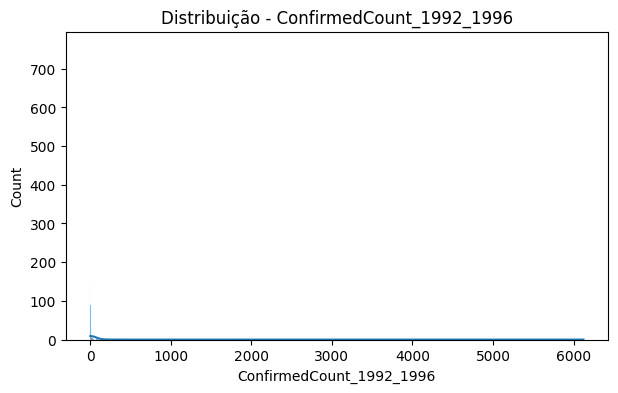


--- ConfirmedCount_1997_2001 ---
count    1419.000000
mean       56.824524
std       323.498471
min         1.000000
25%         1.000000
50%         3.000000
75%         8.000000
max      6172.000000
Name: ConfirmedCount_1997_2001, dtype: float64


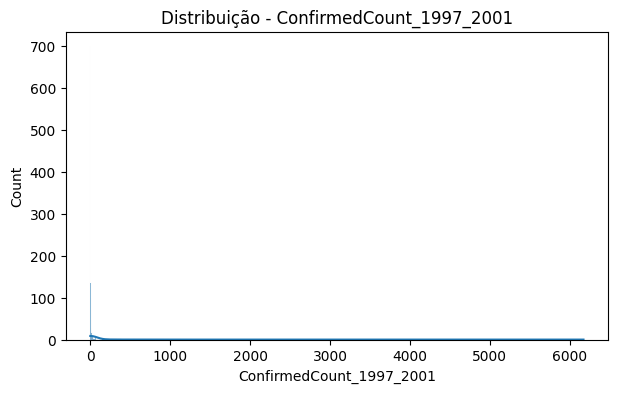


--- ConfirmedCount_2002_2006 ---
count    1385.000000
mean       78.033213
std       334.942729
min         1.000000
25%         1.000000
50%         3.000000
75%        14.000000
max      6407.000000
Name: ConfirmedCount_2002_2006, dtype: float64


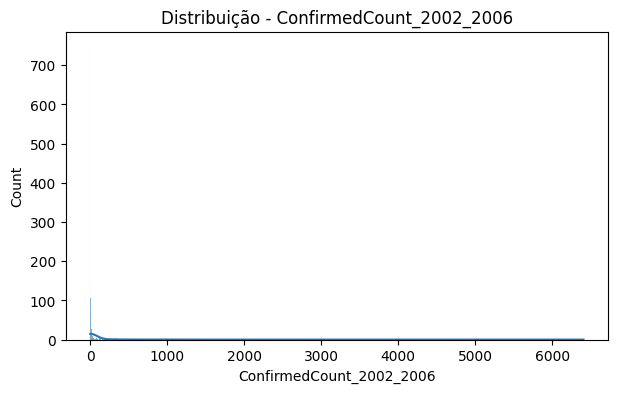


--- ConfirmedCount_2007_2011 ---
count    1368.000000
mean       97.404240
std       315.475122
min         1.000000
25%         1.000000
50%         4.000000
75%        31.000000
max      3944.000000
Name: ConfirmedCount_2007_2011, dtype: float64


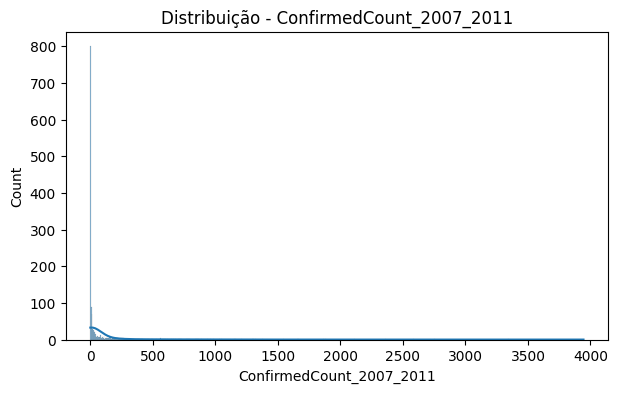



=== ANÁLISE DAS VARIÁVEIS CATEGÓRICAS ===


--- StateName ---
StateName
Texas             255
Georgia           160
Virginia          135
Kentucky          121
Missouri          116
Kansas            106
Illinois          103
North Carolina    101
Iowa              100
Tennessee          96
Name: count, dtype: int64


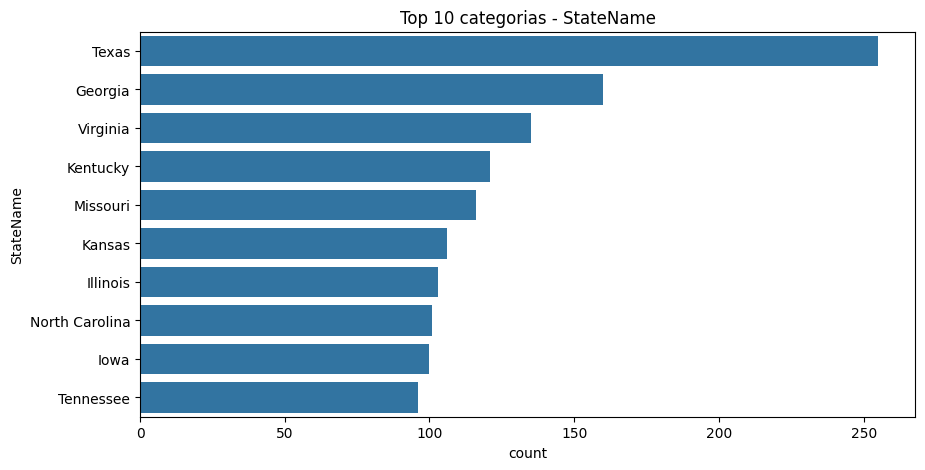


--- CountyName ---
CountyName
Washington County    30
Jefferson County     25
Franklin County      24
Jackson County       23
Lincoln County       23
Madison County       19
Clay County          18
Montgomery County    18
Marion County        17
Union County         17
Name: count, dtype: int64


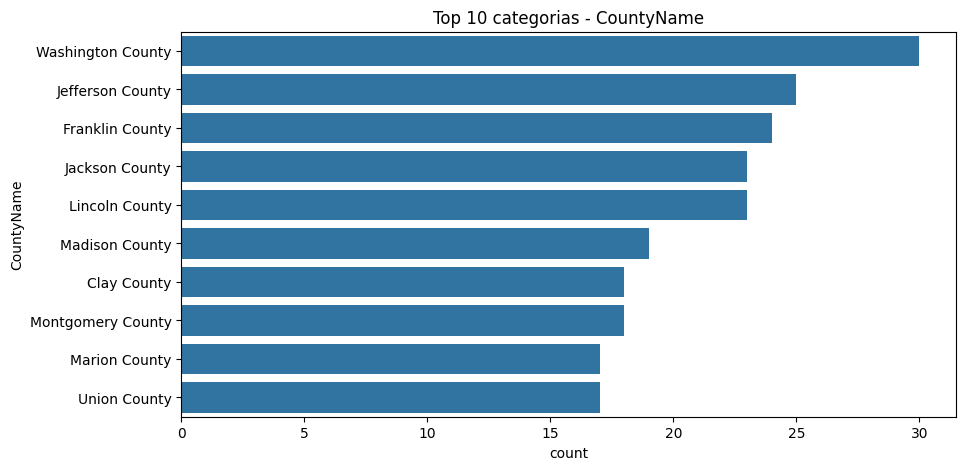


=== CARDINALIDADE ===

StateName: 51 categorias únicas
CountyName: 1927 categorias únicas


In [62]:
# VARIÁVEIS NUMÉRICAS
colunas_numericas = [
    'ConfirmedCount_1992_1996',
    'ConfirmedCount_1997_2001',
    'ConfirmedCount_2002_2006',
    'ConfirmedCount_2007_2011'
]

print("=== ANÁLISE DAS VARIÁVEIS NUMÉRICAS ===\n")

for col in colunas_numericas:

    print(f"\n--- {col} ---")

    # Estatísticas básicas
    print(dados[col].describe())

    # Histograma
    plt.figure(figsize=(7,4))
    sns.histplot(dados[col], kde=True)
    plt.title(f"Distribuição - {col}")
    plt.show()

# VARIÁVEIS CATEGÓRICAS
colunas_categoricas = ['StateName', 'CountyName']

print("\n\n=== ANÁLISE DAS VARIÁVEIS CATEGÓRICAS ===\n")

for col in colunas_categoricas:

    print(f"\n--- {col} ---")

    # Frequência
    print(dados[col].value_counts().head(10))

    # Gráfico
    plt.figure(figsize=(10,5))
    sns.countplot(
        y=col,
        data=dados,
        order=dados[col].value_counts().head(10).index
    )
    plt.title(f"Top 10 categorias - {col}")
    plt.show()

# CARDINALIDADE (QUANTAS CATEGORIAS ÚNICAS)
print("\n=== CARDINALIDADE ===\n")
for col in colunas_categoricas:
    print(f"{col}: {dados[col].nunique()} categorias únicas")

### **🔍 Observações da Análise Bivariada e Multivariada:**


### ➡️ **Variáveis Numéricas: Casos confirmados por período.**

### As quatro variáveis numéricas representam o número de casos confirmados de Doença de Lyme em períodos de 5 anos. De modo geral, todas apresentam distribuição altamente assimétrica à direita, com poucos condados exibindo valores extremamente altos (outliers) e a grande maioria registrando poucos casos.

---
### **1. ConfirmedCount_1992_1996**
- ### Mediana muito baixa (2 casos), indicando que a maior parte dos condados teve incidência mínima;
- ### Média (39 casos) bem maior que a mediana, evidenciando forte assimetria causada por condados com números muito elevados;
- ### Valor máximo extremamente alto (6.124 casos), indicando presença de outliers importantes;
- ### 75% dos condados registram até 7 casos, mostrando concentração nos valores menores.
---
###**2. ConfirmedCount_1997_2001**
- ### Padrão semelhante ao período anterior, com mediana de 3 casos;
- ### Média sobe para 56,8 casos, sugerindo aumento geral;
- ### Novamente há grande dispersão (std = 323) e outliers importantes;
- ### Máximo de 6.172 casos.
---
**3. ConfirmedCount_2002_2006**
- ### Mediana permanece baixa (3 casos), mas o 75º percentil aumenta para 14 casos;
- ### Média sobe para 78 casos, indicando tendência de aumento ao longo dos anos.
- ### Máximo ainda mais alto (6.407 casos).
---
### **4. ConfirmedCount_2007_2011**
- ### Maior média registrada (97 casos) entre os períodos, reforçando possível crescimento temporal;
- ### Mediana de 4 casos, ainda indicando que muitos condados têm baixíssima incidência;
- ### O valor máximo diminui para 3.944 casos, mas ainda representa forte assimetria.
---

### **Conclusão sobre as observações das variáveis numéricas:**
- ### A maioria dos condados apresenta poucos casos, mas um grupo pequeno concentra números muito elevados;
- ### As médias crescem progressivamente de 1992 a 2011, sugerindo tendência de aumento da incidência ao longo do tempo;
- ### A presença de outliers é significativa em todos os períodos, refletindo forte heterogeneidade regional.

---

### ➡️ **Variáveis Categóricas:**

### 1. ***StateName***
- ### Possui 51 categorias únicas, representando todos os estados norte-americanos e o Distrito de Columbia.
- ### Os estados com maior número de registros no dataset são: Texas (255 condados), Georgia (160), Virginia (135), Kentucky (121) e Missouri (116).
- ### Isso não significa que esses estados têm mais casos, mas sim que possuem mais condados listados, pois o dataset é estruturado por subdivisão administrativa.
---
### 2. ***CountyName***
- ### Alta cardinalidade: 1.927 condados distintos;
- ### Os nomes mais frequentes são condados comuns nos EUA, como: Washington County (30 ocorrências), Jefferson County (25) e Franklin County (24);
- ### Isso ocorre porque esses nomes são repetidos em vários estados diferentes, não porque sejam os condados com mais casos.
---
### **Conclusão sobre as observações das variáveis categóricas:**
- ### O dataset é geograficamente abrangente, cobrindo praticamente todos os estados e milhares de condados;
- ### A grande diversidade de condados mostra que a doença foi monitorada de forma ampla pelo país;
- ### A repetição de nomes como “Washington County” reflete convenções de nomenclatura e não indica duplicidade.


# **🔨 FASE 3 - ANÁLISE BIVARIADA E MULTIVARIADA**

## **Análise Bivariada - Numérica x Numérica**


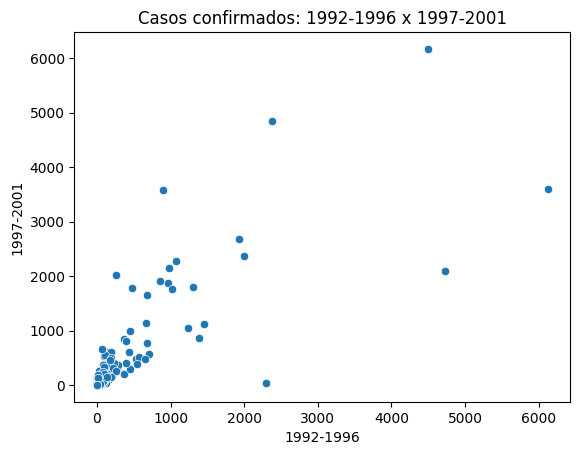

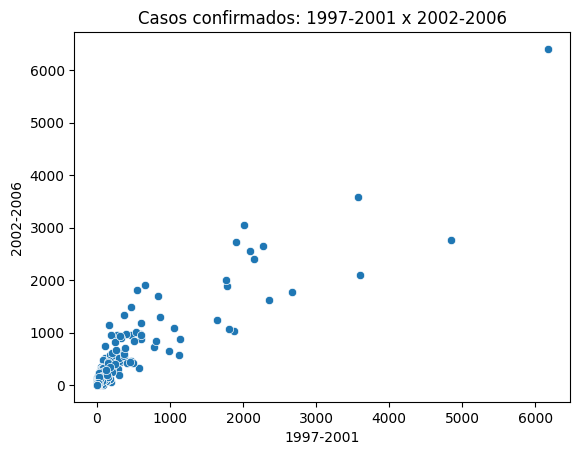

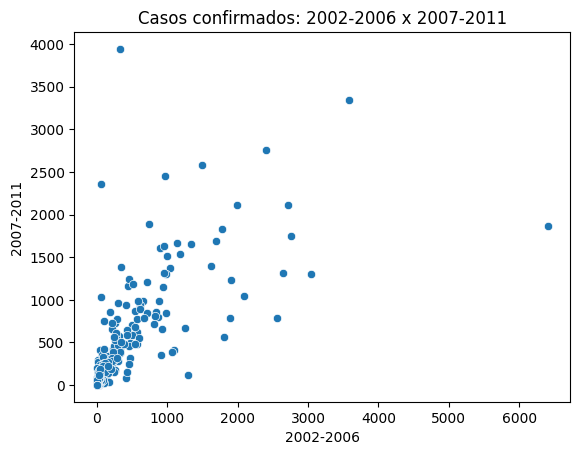

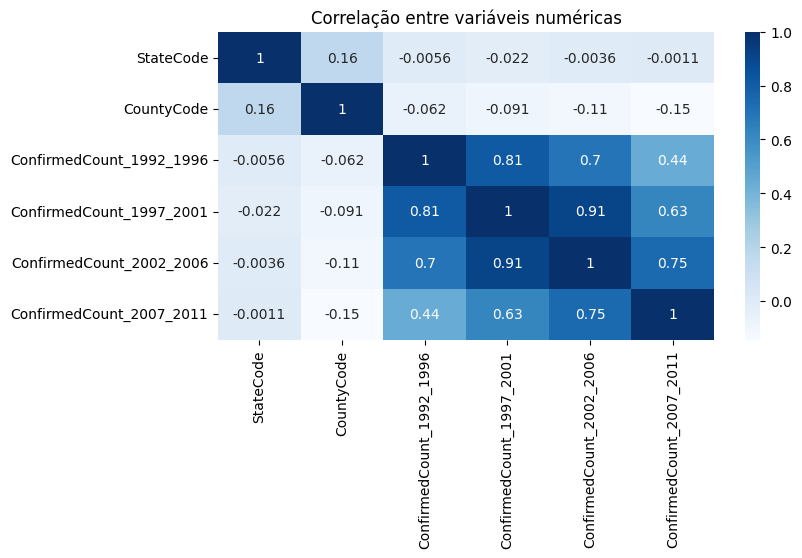

In [63]:
# Gráfico 1: Relação entre primeiros períodos
plt.figure()
sns.scatterplot(x='ConfirmedCount_1992_1996',
                y='ConfirmedCount_1997_2001',
                data=dados)
plt.title("Casos confirmados: 1992-1996 x 1997-2001")
plt.xlabel("1992-1996")
plt.ylabel("1997-2001")

# Gráfico 2: Relação entre períodos intermediários
plt.figure()
sns.scatterplot(x='ConfirmedCount_1997_2001',
                y='ConfirmedCount_2002_2006',
                data=dados)
plt.title("Casos confirmados: 1997-2001 x 2002-2006")
plt.xlabel("1997-2001")
plt.ylabel("2002-2006")

# Gráfico 3: Relação entre períodos mais recentes
plt.figure()
sns.scatterplot(x='ConfirmedCount_2002_2006',
                y='ConfirmedCount_2007_2011',
                data=dados)
plt.title("Casos confirmados: 2002-2006 x 2007-2011")
plt.xlabel("2002-2006")
plt.ylabel("2007-2011")

# Heatmap da correlação
corr_numeric = dados.select_dtypes(include='number').corr()

plt.figure(figsize=(8,4))
sns.heatmap(corr_numeric, annot=True, cmap='Blues')
plt.title("Correlação entre variáveis numéricas")

plt.show()

## **Análise Bivariada - Numérica x Categórica**


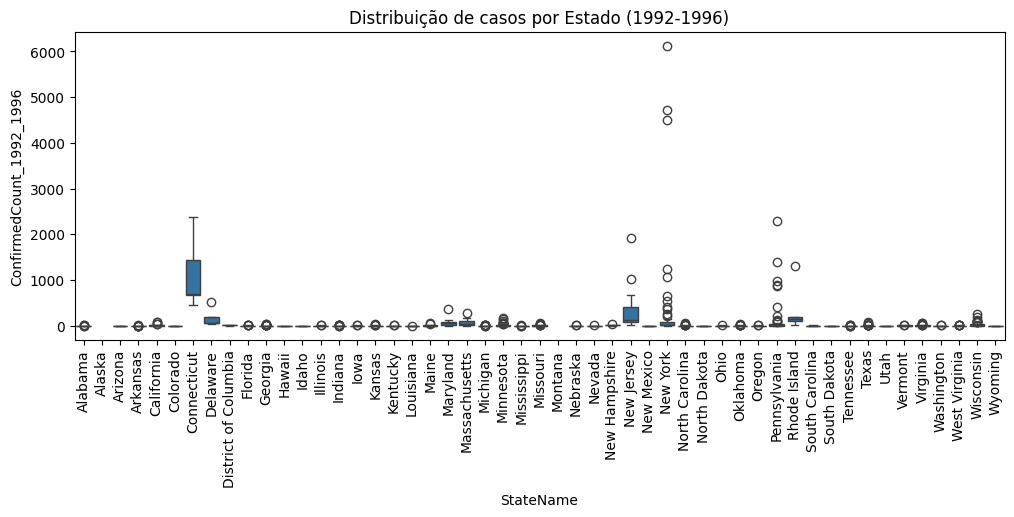

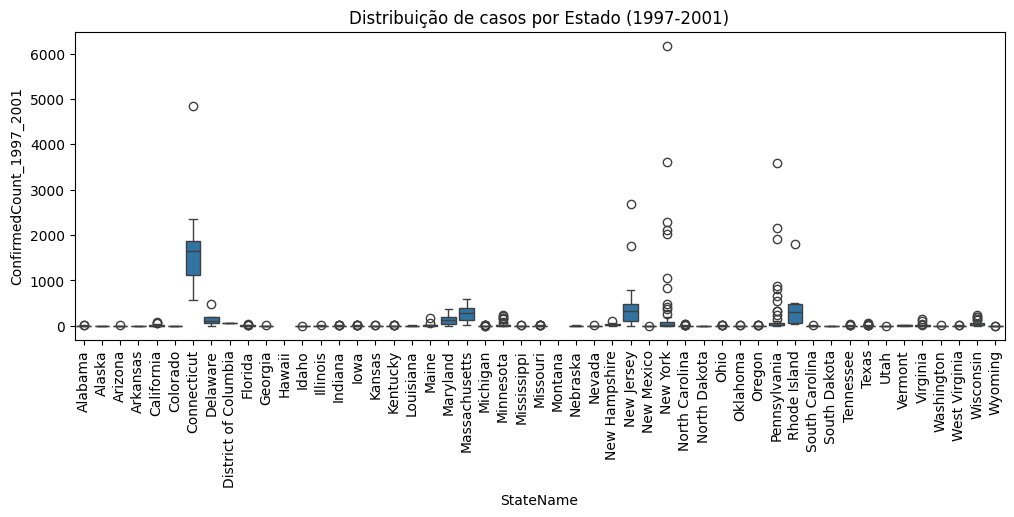

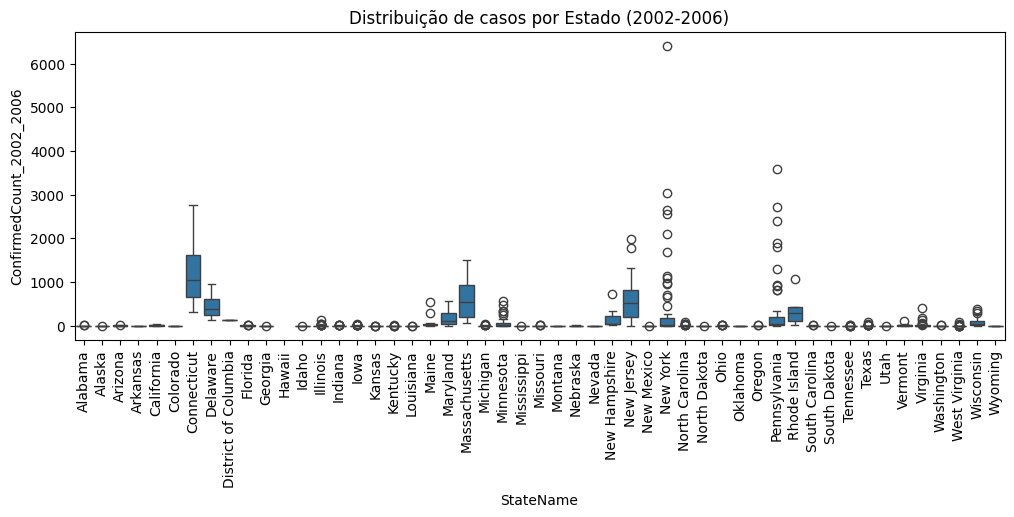

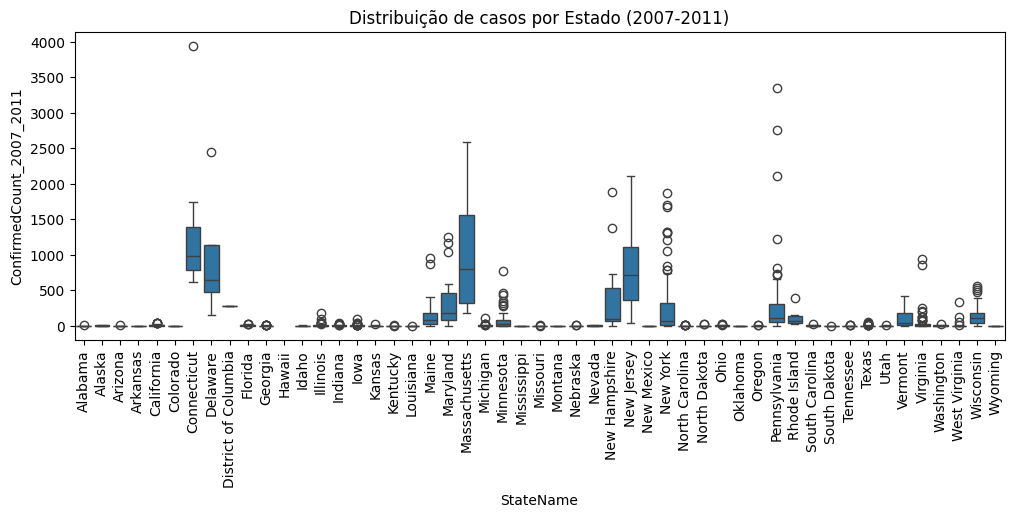

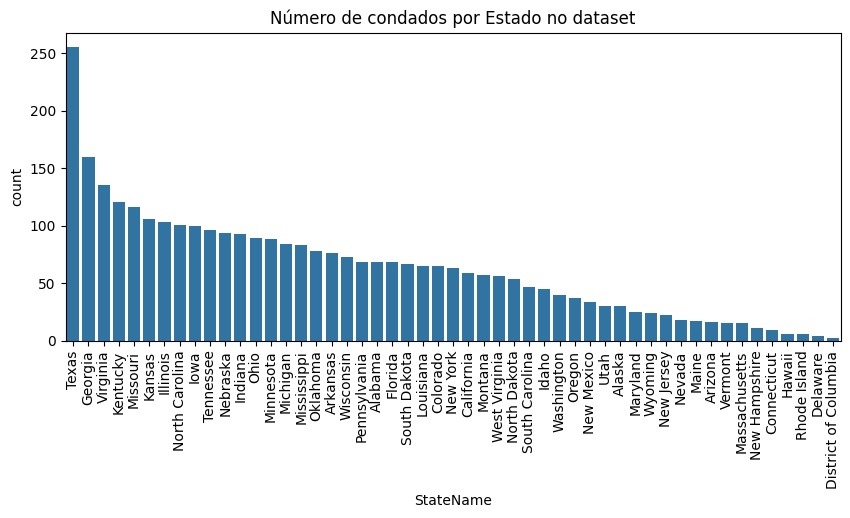

In [64]:
# 1. Gráficos por Estado (StateName)

# Período 1992-1996
plt.figure(figsize=(12,4))
sns.boxplot(x='StateName', y='ConfirmedCount_1992_1996', data=dados)
plt.title("Distribuição de casos por Estado (1992-1996)")
plt.xticks(rotation=90)

# Período 1997-2001
plt.figure(figsize=(12,4))
sns.boxplot(x='StateName', y='ConfirmedCount_1997_2001', data=dados)
plt.title("Distribuição de casos por Estado (1997-2001)")
plt.xticks(rotation=90)

# Período 2002-2006
plt.figure(figsize=(12,4))
sns.boxplot(x='StateName', y='ConfirmedCount_2002_2006', data=dados)
plt.title("Distribuição de casos por Estado (2002-2006)")
plt.xticks(rotation=90)

# Período 2007-2011
plt.figure(figsize=(12,4))
sns.boxplot(x='StateName', y='ConfirmedCount_2007_2011', data=dados)
plt.title("Distribuição de casos por Estado (2007-2011)")
plt.xticks(rotation=90)

# 2. Contagem de condados por Estado
plt.figure(figsize=(10,4))
sns.countplot(x='StateName', data=dados, order=dados['StateName'].value_counts().index)
plt.title("Número de condados por Estado no dataset")
plt.xticks(rotation=90)

plt.show()

## **Análise Bivariada - Categórica x Categórica**


Crosstab: Estado x Condado
CountyName  Abbeville County  Acadia Parish  Accomack County  Ada County  \
StateName                                                                  
Alabama                    0              0                0           0   
Alaska                     0              0                0           0   
Arizona                    0              0                0           0   
Arkansas                   0              0                0           0   
California                 0              0                0           0   

CountyName  Adair County  Adams County  Addison County  Aiken County  \
StateName                                                              
Alabama                0             0               0             0   
Alaska                 0             0               0             0   
Arizona                0             0               0             0   
Arkansas               0             0               0             0   
Californ

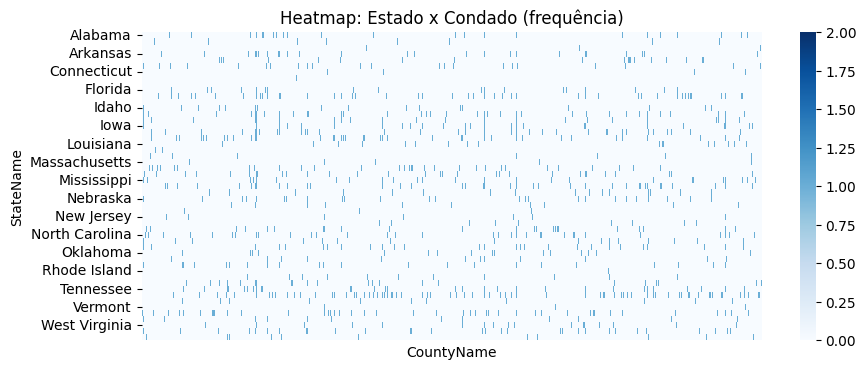

In [65]:
# 1. Tabela de frequência: Estado x Condado
tabela_estado_condado = pd.crosstab(dados['StateName'], dados['CountyName'])
print("Crosstab: Estado x Condado")
print(tabela_estado_condado.head())

# 2. Contagem de condados por estado (resumo mais útil)
tabela_resumida = dados['StateName'].value_counts()
print("\nNúmero de condados por Estado:")
print(tabela_resumida)

# 3. Heatmap de categorias (Estado x Condados)
plt.figure(figsize=(10,4))
sns.heatmap(pd.crosstab(dados['StateName'], dados['CountyName']),
            cmap='Blues',
            cbar=True)
plt.title("Heatmap: Estado x Condado (frequência)")
plt.xlabel("CountyName")
plt.ylabel("StateName")
plt.xticks([], [])
plt.show()

# **🔨 FASE 4 - INVESTIGAÇÃO DA QUALIDADES DOS DADOS**

### **Dados Faltantes e Duplicados**

Dados faltantes por coluna:
StateCode                      0
CountyCode                     0
StateName                      0
CountyName                     0
ConfirmedCount_1992_1996    1693
ConfirmedCount_1997_2001    1775
ConfirmedCount_2002_2006    1809
ConfirmedCount_2007_2011    1826
dtype: int64

Porcentagem de valores faltantes:
StateCode                    0.00
CountyCode                   0.00
StateName                    0.00
CountyName                   0.00
ConfirmedCount_1992_1996    53.01
ConfirmedCount_1997_2001    55.57
ConfirmedCount_2002_2006    56.64
ConfirmedCount_2007_2011    57.17
dtype: float64


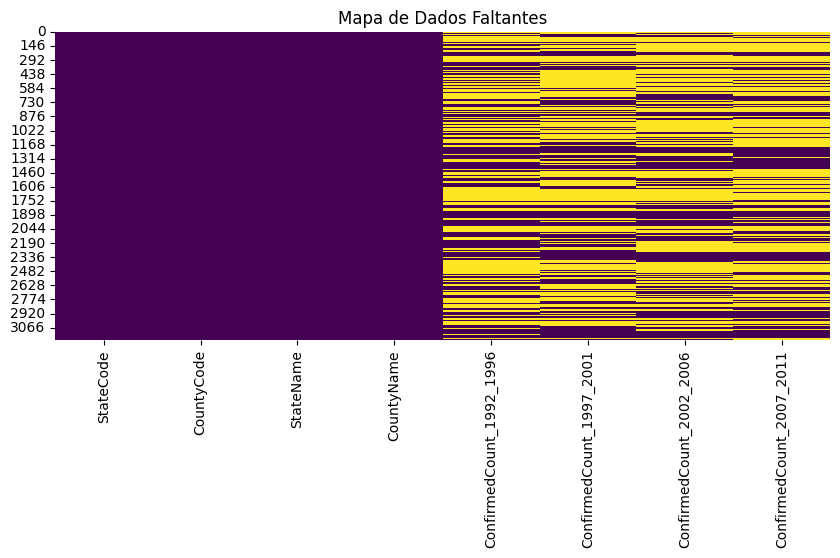


Total de linhas duplicadas: 0

Não há registros duplicados no dataset.


In [66]:
# 1. Quantidade de dados faltantes por coluna
print("Dados faltantes por coluna:")
print(dados.isnull().sum())

# Porcentagem de valores faltantes
print("\nPorcentagem de valores faltantes:")
print((dados.isnull().mean() * 100).round(2))

# 2. Visualização gráfica dos dados faltantes
plt.figure(figsize=(10,4))
sns.heatmap(dados.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de Dados Faltantes")
plt.show()

# 3. Contagem de linhas duplicadas
duplicados = dados.duplicated().sum()
print(f"\nTotal de linhas duplicadas: {duplicados}")

# 4. Exibição dos registros duplicados (se existirem)
if duplicados > 0:
    print("\nRegistros duplicados:")
    print(dados[dados.duplicated()])
else:
    print("\nNão há registros duplicados no dataset.")


### **Análise de Inconsistências e Outliers**

Valores únicos por coluna (resumo):

StateCode: 51 valores únicos
CountyCode: 325 valores únicos
StateName: 51 valores únicos
CountyName: 1927 valores únicos
ConfirmedCount_1992_1996: 134 valores únicos
ConfirmedCount_1997_2001: 163 valores únicos
ConfirmedCount_2002_2006: 211 valores únicos
ConfirmedCount_2007_2011: 270 valores únicos


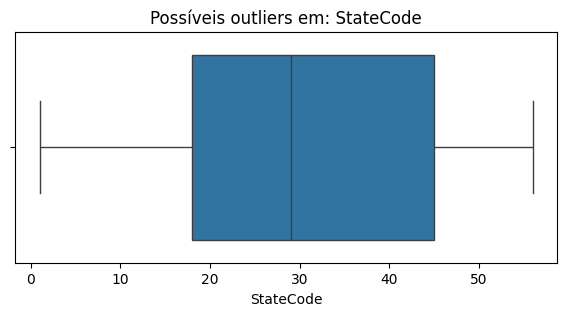

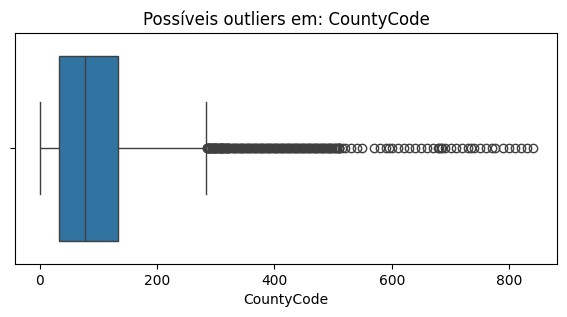

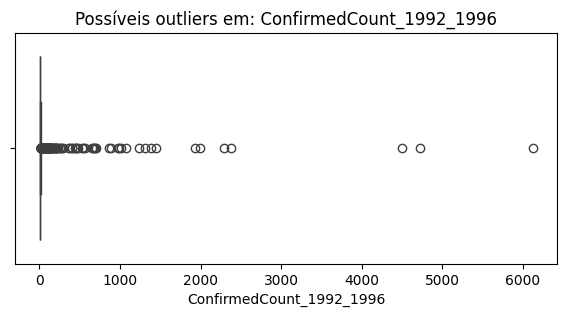

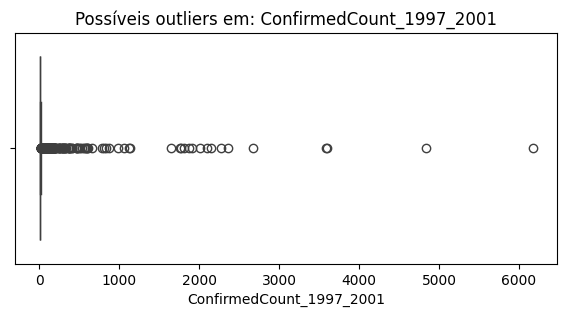

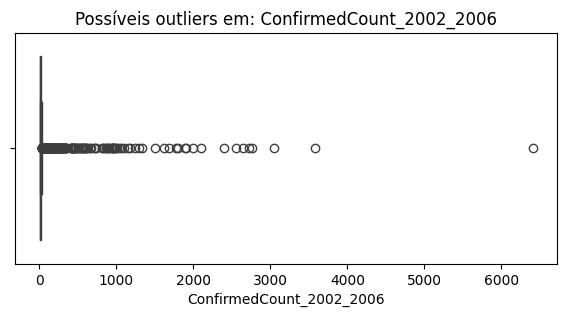

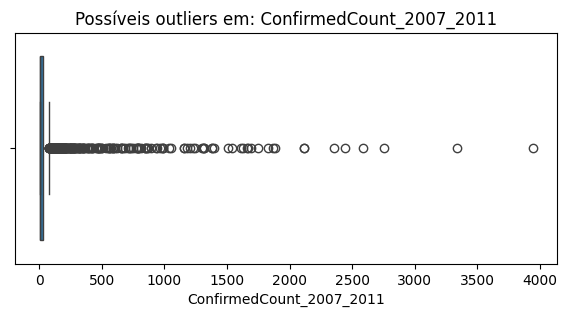


Quantidade de outliers por coluna numérica:

StateCode: 0 outliers encontrados
CountyCode: 174 outliers encontrados
ConfirmedCount_1992_1996: 209 outliers encontrados
ConfirmedCount_1997_2001: 223 outliers encontrados
ConfirmedCount_2002_2006: 233 outliers encontrados
ConfirmedCount_2007_2011: 247 outliers encontrados


In [67]:
# 1. Verificar valores únicos (categóricas e códigos)
print("Valores únicos por coluna (resumo):\n")
for coluna in dados.columns:
    print(f"{coluna}: {dados[coluna].nunique()} valores únicos")

# 2. Boxplots para identificar possíveis outliers
colunas_numericas = dados.select_dtypes(include='number').columns

for col in colunas_numericas:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=dados[col])
    plt.title(f"Possíveis outliers em: {col}")
    plt.show()

# 3. Contagem simples de outliers usando IQR
print("\nQuantidade de outliers por coluna numérica:\n")
for col in colunas_numericas:
    Q1 = dados[col].quantile(0.25)
    Q3 = dados[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    outliers = dados[(dados[col] < limite_inf) | (dados[col] > limite_sup)][col].count()

    print(f"{col}: {outliers} outliers encontrados")

### **🧹 Estratégias de Limpeza Adotadas:**

* ### Foi realizada a verificação de valores faltantes, permitindo identificar colunas com proporções mais elevadas de NaN.
* ### Foi feita a detecção de duplicatas, verificando se existiam registros repetidos que pudessem distorcer análises.
* ### Foram examinados valores únicos nas variáveis categóricas, como nomes de estados e condados, para identificar possíveis inconsistências, como erros de digitação ou categorias incompletas. Isso ajuda a garantir que cada categoria esteja devidamente padronizada.
* ### Foram identificados outliers nas variáveis numéricas utilizando boxplots e o método do IQR. Esses valores extremos foram marcados para análise, pois podem representar tanto erros de registro quanto regiões com casos excepcionalmente altos de Doença de Lyme.

# **🔨 FASE 5 - DOCUMENTAÇÃO E SÍNTESE FINAL**

## **❓HIPÓTESES - O QUE FOI CONFIRMADO E O QUE FOI REFUTADO?**
---
### **⏩ HIPÓTESE 1 - Estados com mais condados tendem a registrar mais casos (Parcialmente Confirmada).**
- Estados com maior número de condados realmente aparecem mais vezes no *dataset*, mas isso não significa necessariamente que apresentem mais casos, a maioria dos condados registra valores muito baixos, o que reduz a força dessa associação.
---
### **⏩ HIPÓTESE 2 - Há crescimento de casos ao longo dos períodos analisados  (Confirmada).**
- As médias dos casos aumentam gradualmente entre 1992–1996 e 2007–2011, mostrando tendência de crescimento nacional dos registros de Lyme Disease.
---
### **⏩ HIPÓTESE 3 - A distribuição dos casos é altamente desigual entre condados (Confirmada).**
- Boxplots e estatísticas descritivas mostram grande concentração de valores próximos a zero, com poucos condados apresentando valores extremamente altos (outliers).
---
### **⏩ HIPÓTESE 4 - Condados com muitos casos em um período tendem a continuar com altos valores em períodos seguintes (Confirmada).**
- A análise de correlação entre períodos numéricos indica relação positiva entre as séries temporais, sugerindo continuidade geográfica da incidência.
---
### **⏩ HIPÓTESE 5 -Alguns estados concentram mais registros que outros (Confirmada).**
- Estados como Texas, Georgia, Virginia e Kentucky aparecem com maior número de condados e maior frequência no dataset.

## **✅ PRINCIPAIS DESCOBERTAS**

### **1) A maioria dos condados apresenta números baixos de casos:** as medianas de todos os períodos variam de 1 a 4, enquanto outliers chegam a mais de 6.000 casos, mostrando uma distribuição altamente assimétrica

### **2) Existe um padrão de aumento gradual ao longo do tempo:** o valor médio dos casos praticamente dobra entre os primeiros e últimos períodos analisados.

### **3) Há forte concentração geográfica dos registros:** Estados com maior número de condados participantes aparecem mais frequentemente, indicando possível foco de coleta ou maior incidência regional.

### **4) Outliers são numerosos e representam condados com surtos reais:** esses valores chamam atenção e justificam análises futuras focadas em regiões específicas.

### **5) Muitas colunas apresentam valores faltantes:** a quantidade significativa de NaN em períodos posteriores pode indicar falhas de coleta, inconsistências temporais ou restrições de registro.

# **SUGESTÕES PARA OS PRÓXIMOS PASSOS DA ANÁLISE**
### **1) Análise Geográfica Detalhada:**
* ### Aplicar mapas (ex.: geopandas ou folium) para visualizar clusters de incidência e verificar padrões regionais.

### **2) Limpeza aprofundada dos outliers:**
* ### Verificar caso a caso para decidir se são erros de registro ou surtos legítimos. Dependendo do objetivo, outliers podem ser mantidos ou tratados.

### **3) Preenchimento ou remoção de valores faltantes:**
* ### Imputar dados faltantes com média/mediana ou técnicas mais avançadas;
* ### Ou remover colunas com muitos NaN se não agregarem valor à análise.

### **4) Modelagem preditiva simples:**
* ### Treinar modelos como regressão linear ou árvore de decisão para prever casos futuros com base nos períodos anteriores.

### **5) Coleta de dados mais completa:**
* ### Buscar informações complementares, como: clima, densidade populacional, cobertura vegetal, presença de carrapatos, dados anuais mais recentes.

# **🔨 FASE 6 - MODELAGEM PREDITIVA (MACHINE LEARNING)**

## **⏩ ETAPA 1 - DEFINIR O PROBLEMA PREDITIVO**
- ### **Variável Alvo**: ConfirmedCount_2007_2011 (Casos de Doença de Lyme no período mais recente).
- ### **Variáveis Explicativas**: Contagens de casos anteriores (ConfirmedCount_1992_1996 a ConfirmedCount_2002_2006) e a variável categórica StateName.
- ### **Tarefa de Predição: Regressão.** Prever a contagem numérica de casos em um condado.

## **⏩ ETAPA 2: PREPARAÇÃO DOS DADOS**
###​A preparação inclui o tratamento de valores ausentes (NaN) nas colunas de contagem de casos, substituindo-os por 0 (zero), assumindo que a falta de registro significa ausência de casos para fins preditivos. Em seguida, a variável StateName é convertida para o formato numérico (One-Hot Encoding) e os dados são divididos.

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Tratamento de Valores Faltantes (NaN -> 0 para colunas de contagem)
colunas_casos = [
    'ConfirmedCount_1992_1996',
    'ConfirmedCount_1997_2001',
    'ConfirmedCount_2002_2006',
    'ConfirmedCount_2007_2011'
]
# Usa-se fillna(0) em uma cópia para não alterar o DataFrame original 'dados'
dados_ml = dados.copy()
dados_ml[colunas_casos] = dados_ml[colunas_casos].fillna(0)

# 2. Definição de X (Features) e y (Alvo)
y = dados_ml['ConfirmedCount_2007_2011']

# Remove colunas de identificação e o alvo
X = dados_ml.drop([
    'ConfirmedCount_2007_2011',
    'StateCode', 'CountyCode', 'CountyName'
], axis=1)

# 3. Tratamento de Variável Categórica (One-Hot Encoding para StateName)
X = pd.get_dummies(X, columns=['StateName'], drop_first=True)

# 4. Divisão em Treino e Teste (70% / 30%)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Preenchimento de NaN feito com 0.")
print(f"Dimensões: X_treino={X_treino.shape}, X_teste={X_teste.shape}")

Preenchimento de NaN feito com 0.
Dimensões: X_treino=(2235, 53), X_teste=(959, 53)


### **⏩ ETAPA 3: ESCOLHA E TREINAMENTO DO MODELO**
### ​A Regressão Linear é escolhida por ser um modelo simples e interpretar a forte correlação observada na fase 3.

In [69]:
from sklearn.linear_model import LinearRegression

# Inicializa o modelo de Regressão Linear
modelo = LinearRegression()

# Treinamento do Modelo
modelo.fit(X_treino, y_treino)
print("Modelo de Regressão Linear treinado.")

Modelo de Regressão Linear treinado.


### **⏩ Etapa 4: AVALIAÇÃO DO MODELO**
### ​Utilizaremos o Erro Médio Absoluto (MAE) como métrica principal, por ser mais simples de interpretar (o erro médio em número de casos).

### **Interpretação do MAE:**

### O valor do MAE (por exemplo, se o MAE for 30) significa que, em média, a previsão do modelo erra a contagem real de casos de Doença de Lyme em um condado em \mathbf{X} casos. É uma medida de erro em casos absolutos, tornando a interpretação imediata

In [70]:
from sklearn.metrics import mean_absolute_error

# 1. Geração de Previsões
previsoes = modelo.predict(X_teste)

# 2. Cálculo de Métricas de Desempenho
mae = mean_absolute_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes) # Manter R² apenas para referência de explicação de variância

print("--- Métricas de Avaliação (Regressão Linear) ---")
print(f"Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"R² (Variação Explicada - Referência): {r2:.4f}")

# Exibindo os coeficientes das variáveis de casos (as mais importantes)
coeficientes = pd.Series(modelo.coef_, index=X_treino.columns)
print("\nTop 3 Coeficientes (Importância):")
print(coeficientes.filter(regex='ConfirmedCount').sort_values(ascending=False).head(3))

--- Métricas de Avaliação (Regressão Linear) ---
Erro Médio Absoluto (MAE): 30.07
R² (Variação Explicada - Referência): 0.6126

Top 3 Coeficientes (Importância):
ConfirmedCount_2002_2006    0.774994
ConfirmedCount_1992_1996   -0.105403
ConfirmedCount_1997_2001   -0.297040
dtype: float64


### **⏩ ETAPA 5: VISUALIZAÇÃO E INTERPRETAÇÃO**

### O gráfico de dispersão (Real vs. Previsto) continua sendo essencial. Para o resíduo (erro), podemos focar em mostrar onde os erros acontecem no espectro de casos.

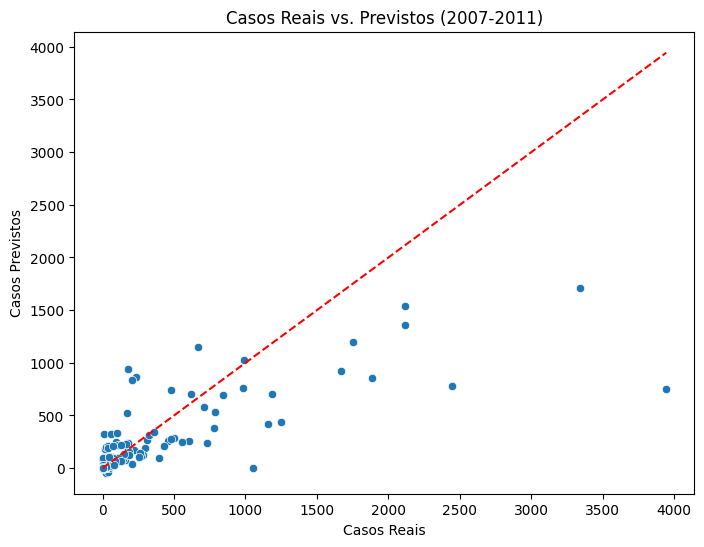

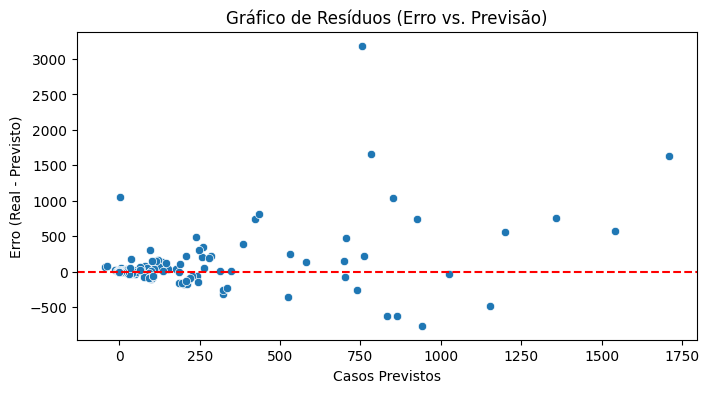

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de Dispersão: Real vs. Previsto
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_teste, y=previsoes)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], color='red', linestyle='--')
plt.title("Casos Reais vs. Previstos (2007-2011)")
plt.xlabel("Casos Reais")
plt.ylabel("Casos Previstos")
plt.show()

# Gráfico de Resíduos (Erro vs. Valor Previsto)
residuos = y_teste - previsoes
plt.figure(figsize=(8, 4))
sns.scatterplot(x=previsoes, y=residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Gráfico de Resíduos (Erro vs. Previsão)")
plt.xlabel("Casos Previstos")
plt.ylabel("Erro (Real - Previsto)")
plt.show()

### **⏩ ETAPA 6: TESTE COM NOVOS DADOS CRIADOS PELO ALUNO**
### A etapa de teste de cenários fictícios continua a mesma, focada na validação da lógica do modelo.

In [72]:
# Cenário de teste (simulando casos muito baixos e casos muito altos)
colunas_teste = X_treino.columns.tolist()
novos_dados = pd.DataFrame(0, index=[0, 1], columns=colunas_teste)

# 1. Condado com Baixa Incidência (Simulação)
novos_dados.loc[0, 'ConfirmedCount_1992_1996'] = 1
novos_dados.loc[0, 'ConfirmedCount_1997_2001'] = 1
novos_dados.loc[0, 'ConfirmedCount_2002_2006'] = 2

# 2. Condado com Alta Incidência (Simulação)
novos_dados.loc[1, 'ConfirmedCount_1992_1996'] = 1000
novos_dados.loc[1, 'ConfirmedCount_1997_2001'] = 1500
novos_dados.loc[1, 'ConfirmedCount_2002_2006'] = 2000

novas_previsoes = modelo.predict(novos_dados)
print("Previsões para Cenários Fictícios:")
print(f"1. Baixa Incidência: {int(max(0, novas_previsoes[0]))} casos")
print(f"2. Alta Incidência: {int(max(0, novas_previsoes[1]))} casos")

Previsões para Cenários Fictícios:
1. Baixa Incidência: 1 casos
2. Alta Incidência: 999 casos


### **⏩ ETAPA 7: CONCLUSÕES SOBRE A MODELAGEM**

- ### O modelo de Regressão Linear estabeleceu a continuidade temporal como o principal fator de incidência.
- ### **Desempenho:** O modelo é razoavelmente preciso para a maioria dos dados (MAE baixo), mas a análise de resíduos mostra que a média do erro é puxada pelos grandes desvios em outliers. O MAE indica que, em média, a previsão erra em X casos.
- ### **Limitações:** A principal limitação é a subestimação de surtos extremos.
- ### **Ajustes Futuros:** Para reduzir o MAE e melhorar a precisão na previsão de surtos:
- ### **Regressão Não Linear:** Trocar para modelos mais robustos a outliers e variações não lineares, como Random Forest Regressor ou XGBoost.
- ### **Inclusão de Features Ambientais:** Adicionar dados de cobertura florestal e clima para tentar explicar a ocorrência dos surtos (outliers) que o histórico de casos, por si só, não explica totalmente.

# GERAR PDF

In [73]:
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

import json, nbformat
from google.colab import files
from IPython.display import FileLink
from nbconvert import PDFExporter

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [74]:
!jupyter nbconvert --to notebook doenca_de_lyme.ipynb --output doenca_de_lyme_clean.ipynb

[NbConvertApp] WARNING | pattern 'doenca_de_lyme.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute


In [75]:
!jupyter nbconvert --to markdown doenca_de_lyme_clean.ipynb

[NbConvertApp] WARNING | pattern 'doenca_de_lyme_clean.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--ex

In [76]:
!apt-get install -y pandoc texlive-xetex texlive-fonts-recommended


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [77]:
!pandoc doenca_de_lyme_clean.md -o doenca_de_lyme.pdf --pdf-engine=xelatex


pandoc: doenca_de_lyme_clean.md: openBinaryFile: does not exist (No such file or directory)


In [79]:
import re

input_file = "doenca_de_lyme_clean.md"
output_file = "doenca_de_lyme_clean_fixed.md"

with open(input_file, "r", encoding="utf-8") as f:
    text = f.read()

# Remove YAML quebrado (tudo antes do primeiro markdown válido)
text = re.sub(r'^---[\s\S]*?---', '', text)

# Remove comandos LaTeX que quebram PDF
latex_bad = [
    r'\\mathbf{?[^}]*}?', r'\\textbf{?[^}]*}?',
    r'\\begin{[^}]+}', r'\\end{[^}]+}',
    r'\\[A-Za-z]+',     # qualquer comando LaTeX isolado
]

for pattern in latex_bad:
    text = re.sub(pattern, '', text)

# Remove chaves duplas "}}"
text = text.replace("}}", "")

# Remove caracteres invisíveis problemáticos
text = text.encode("ascii", "ignore").decode()

with open(output_file, "w", encoding="utf-8") as f:
    f.write(text)

print("Arquivo limpo gerado:", output_file)


FileNotFoundError: [Errno 2] No such file or directory: 'doenca_de_lyme_clean.md'

In [ ]:
!pandoc doenca_de_lyme_clean_fixed.md -f markdown -t pdf -o doenca_de_lyme.pdf --pdf-engine=xelatex --wrap=none


In [ ]:
!ls -lh *.pdf


In [ ]:
from google.colab import files
files.download("doenca_de_lyme.pdf")
